## **<font color="red">Logistic Regression</font>**
### **<font color="blue">Method 01: Perceptron Trick</font>**

Learned bias: -0.20000000000000004
Learned weights: [ 0.33012505 -0.19348858]
Full weight vector (bias first): [-0.2         0.33012505 -0.19348858]
Train accuracy: 98.86%
Test accuracy:  99.33%


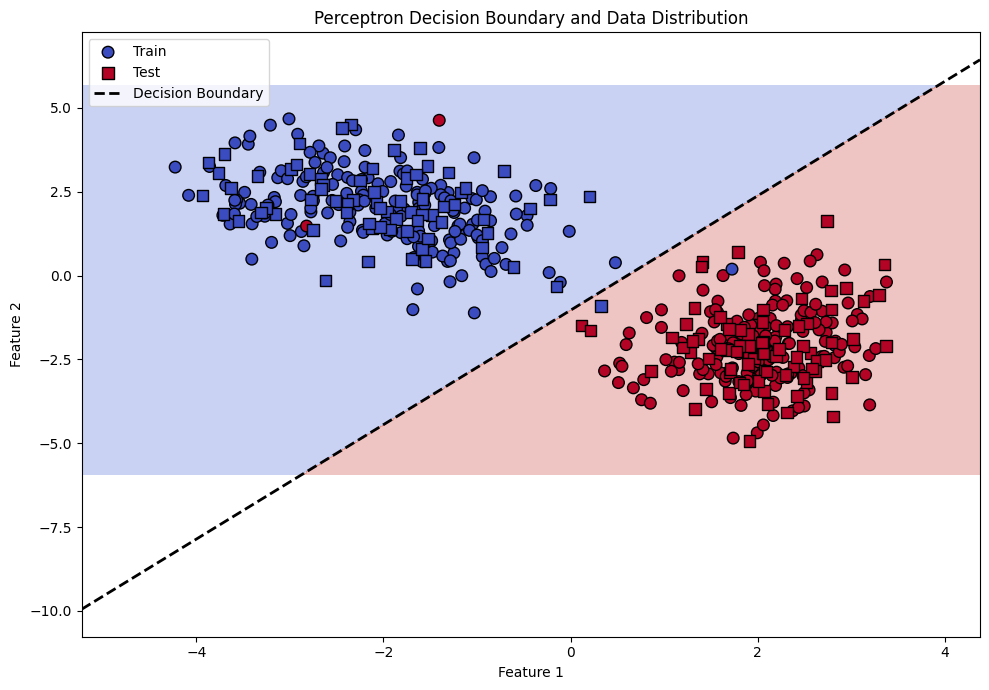

In [8]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# =========================================================================
def perceptron(X_train, y_train, lr=0.1, epochs=1000):
    step = lambda z: 1 if z >= 0 else 0
    
    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train).astype(int)
    n_samples, n_features = X_train.shape

    # add bias column (constant 1)
    Xb = np.insert(X_train, 0, 1, axis=1)

    # initialize weights (bias + features)
    weights = np.zeros(n_features + 1)
    
    for epoch in range(epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        for i in indices:
            xi = Xb[i]
            yi = y_train[i]
            y_hat = step(np.dot(xi, weights))
            weights = weights + lr * (yi - y_hat) * xi

    bias = weights[0]
    w = weights[1:]
    return bias, w, weights

def perceptron_predict(X_test, weights_full):
    X_test = np.insert(X_test, 0, 1, axis=1)
    scores = np.dot(X_test, weights_full)
    y_pred = (scores >= 0).astype(int)
    return y_pred

# =========================================================================

# Dataset
np.random.seed(41)
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41, class_sep=2.0)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Model
bias, w, weights_full = perceptron(X_train, y_train, lr=0.1, epochs=100)
print("Learned bias:", bias)
print("Learned weights:", w)
print("Full weight vector (bias first):", weights_full)

# Predict
train_preds = perceptron_predict(X_train, weights_full)
test_preds = perceptron_predict(X_test, weights_full)
train_acc = np.mean(train_preds == y_train)
test_acc = np.mean(test_preds == y_test)
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy:  {test_acc*100:.2f}%")

# Plots
plt.figure(figsize=(10, 7))

# Define meshgrid for decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Compute predictions over grid
grid = np.c_[xx.ravel(), yy.ravel()]
grid_with_bias = np.insert(grid, 0, 1, axis=1)
Z = np.dot(grid_with_bias, weights_full)
Z = (Z >= 0).astype(int).reshape(xx.shape)

# Plot decision boundary background
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Plot training and test data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', marker='o', edgecolor='k', s=70, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='s', edgecolor='k', s=70, label='Test')

# Decision boundary line: w0 + w1*x + w2*y = 0  =>  y = -(w0 + w1*x)/w2
x_vals = np.linspace(x_min, x_max, 200)
y_vals = -(weights_full[0] + weights_full[1] * x_vals) / weights_full[2]
plt.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2, label='Decision Boundary')

# Labels and legend
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Decision Boundary and Data Distribution")
plt.legend()
plt.tight_layout()
plt.show()


## **Animation**

In [19]:
# Jupyter cell — ONLY the per-epoch animation (no extra static plots)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

def perceptron_train_record_epoch(X_train, y_train, lr=0.1, epochs=30, shuffle=True, stop_on_converge=True):
    X = np.asarray(X_train, dtype=float)
    y = np.asarray(y_train, dtype=int).ravel()
    n_samples, n_features = X.shape
    Xb = np.insert(X, 0, 1.0, axis=1)
    weights = np.zeros(n_features + 1, dtype=float)
    weights_per_epoch = []
    for ep in range(int(epochs)):
        idx = np.arange(n_samples)
        if shuffle:
            np.random.shuffle(idx)
        updates = 0
        for i in idx:
            xi = Xb[i]
            yi = int(y[i])
            score = float(np.dot(xi, weights))
            y_hat = 1 if score >= 0 else 0
            err = yi - y_hat
            if err != 0:
                weights += lr * err * xi
                updates += 1
        weights_per_epoch.append(weights.copy())
        if stop_on_converge and updates == 0:
            break
    return weights_per_epoch, weights.copy()

def clear_artists(ax):
    for coll in list(ax.collections):
        try: coll.remove()
        except Exception: pass
    for ln in list(ax.lines):
        try: ln.remove()
        except Exception: pass
    for art in list(ax.artists):
        try: art.remove()
        except Exception: pass
    for txt in list(ax.texts):
        try: txt.remove()
        except Exception: pass

def animate_epochs_inline_only(X, y, weights_per_epoch, interval_ms=300, figsize=(7,6), gif_name="perceptron_epochs.gif"):
    assert X.shape[1] == 2, "2D features required."
    pad = 1.0
    x_min, x_max = X[:,0].min() - pad, X[:,0].max() + pad
    y_min, y_max = X[:,1].min() - pad, X[:,1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220),
                         np.linspace(y_min, y_max, 220))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_b = np.insert(grid, 0, 1.0, axis=1)

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap('coolwarm')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])

    Xb = np.insert(X, 0, 1.0, axis=1)
    boundary_line, = ax.plot([], [], 'k--', lw=1.5)

    def update(frame):
        clear_artists(ax)
        w = weights_per_epoch[frame]
        grid_scores = grid_b.dot(w).reshape(xx.shape)
        Z = (grid_scores >= 0).astype(int)
        ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap)
        ax.scatter(X[:,0], X[:,1], c=y, cmap=cmap, edgecolor='k', s=60)
        preds = (Xb.dot(w) >= 0).astype(int)
        mis_idx = np.where(preds != y)[0]
        if mis_idx.size:
            ax.scatter(X[mis_idx,0], X[mis_idx,1], facecolors='none', edgecolors='red',
                       s=160, linewidths=2, marker='o')
        w0, w1, w2 = w[0], w[1], w[2]
        eps = 1e-9
        if abs(w2) > eps:
            x_vals = np.array([x_min, x_max])
            y_vals = -(w0 + w1 * x_vals) / w2
            boundary_line.set_data(x_vals, y_vals)
            ax.add_line(boundary_line)
        elif abs(w1) > eps:
            xv = -w0 / w1
            boundary_line.set_data([xv, xv], [y_min, y_max])
            ax.add_line(boundary_line)
        else:
            boundary_line.set_data([], [])
        return []

    anim = animation.FuncAnimation(fig, update, frames=len(weights_per_epoch), interval=interval_ms, blit=False)

    # Try inline display; close figure before displaying to avoid static render
    try:
        from IPython.display import HTML, display
        html = anim.to_jshtml()
        plt.close(fig)
        display(HTML(html))
        return anim
    except Exception:
        try:
            anim.save(gif_name, writer='pillow', fps=int(1000/interval_ms) if interval_ms>0 else 5)
            from IPython.display import Image, display
            plt.close(fig)
            display(Image(filename=gif_name))
            return anim
        except Exception:
            plt.close(fig)
            return anim

# ---------------- Demo (shows only animation)
np.random.seed(41)
X, y = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41, class_sep=1.6)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

weights_per_epoch, final_w = perceptron_train_record_epoch(X_train, y_train, lr=0.12, epochs=50, shuffle=True)
anim = animate_epochs_inline_only(X_train, y_train, weights_per_epoch, interval_ms=300, figsize=(7,6))
